In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output



In [2]:
df = pd.read_csv("data_images.csv")
df = df.iloc[np.random.permutation(len(df))]
valid_labels = ["id", "ood"]
name = input("Tell me your name pls: ")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


6.527%
(224, 224, 3)


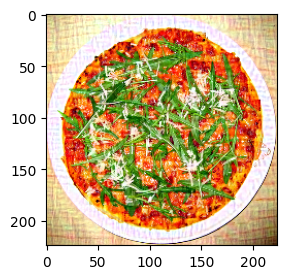

KeyboardInterrupt: Interrupted by user

In [3]:
my_label = []
count = 1
tot = len(df)
for i in range(len(df)):
    print(f"{count/tot * 100:.4}%")
    image_info = df.iloc[i]
    image_loc = image_info["file"]
    
    #print(image_info["source"])
    img = np.load("images/"+image_loc)[0]
    print(img.shape)
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.show()

    relabel = ""
    while relabel not in valid_labels:    
        relabel = input("Entry new label (id/ood)").strip().lower()
        
    my_label.append(relabel)
    count += 1
    clear_output(wait=True)

clear_output(wait=True)

In [4]:
print(f"That's all! Thank you very much, {name}!")
df[f"{name}_labels"] = my_label
df.to_csv("data.csv", header=True, index=False)

That's all! Thank you very much, matteo!


In [6]:
input("")

final_labels = []
for i in range(len(df)):
    if df["matteo_labels"].iloc[i] == df["flo_labels"].iloc[i]:
        if df["matteo_labels"].iloc[i] == "id": final_labels.append("id")
        elif df["matteo_labels"].iloc[i] == "ood": final_labels.append("ood")
    else:
        final_labels.append("?")
df["ID/OOD Human"] = final_labels

In [8]:
df["ID/OOD Human"].value_counts()

final_labels
id     322
ood     80
?       27
Name: count, dtype: int64

In [9]:
df.to_csv("data.csv", header=True, index=False)

In [10]:
for i in range(len(df)):
    image_info = df.iloc[i]
    image_loc = image_info["file"]
    if image_info["ID/OOD Human"] != "?": continue
        
    img = np.load("images/"+image_loc)[0]
    print(img.shape)
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.show()

    input()
    clear_output(wait=True)

clear_output(wait=True)

100.2%
100.2%
100.2%
100.2%
100.2%
100.2%
100.2%
100.2%
100.2%
100.2%
